# NAFNet-Tiny: Semiconductor Image Restoration
**Team Semigone | Semicon India Hackathon 2026**

> Model: NAFNet-Tiny (0.48M params) | Joint Denoise + 2x SR | Charbonnier + SSIM Loss


## 0. GPU Check


In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU! Go to Runtime > Change runtime type > T4 GPU")


PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Memory: 15.6 GB


## 1. Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Clone Repo & Install Dependencies


In [3]:
import os
REPO = '/content/semicon-restore'

if os.path.exists(REPO):
    !cd {REPO} && git pull
else:
    !git clone https://github.com/Luv120/Semigone.git {REPO}

%cd {REPO}
!pip install -r requirements.txt -q
print("\nSetup complete!")


Cloning into '/content/semicon-restore'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 55 (delta 18), reused 42 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 2.38 MiB | 5.51 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/semicon-restore

Setup complete!


## 3. Configure Paths

Your Google Drive folder structure:
```
MyDrive/Drop/
├── train/
│   ├── GT/          ← Clean ground truth images
│   └── NoisyLR/     ← Degraded noisy input images
├── test/  (or NoisyLR/)
│   ├── GT/          ← Test ground truth (if available)
│   └── NoisyLR/     ← Test noisy images
├── train.zip
└── Test_NoisyLR.zip
```


In [4]:
import os

# ═══════════════════════════════════════════════════════════
# MAIN CONFIG - Edit these paths to match your Drive
# ═══════════════════════════════════════════════════════════
DATA_DIR  = '/content/drive/MyDrive/Drop'
SAVE_DIR  = '/content/drive/MyDrive/semicon-checkpoints'
CONFIG    = 'configs/default.yaml'

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Auto-detect folder structure ──
print("=" * 60)
print("SCANNING YOUR DATASET FOLDER")
print("=" * 60)

# Find training folders
train_gt = None
train_lr = None
test_lr = None
test_gt = None

# Common folder name patterns
gt_names = ['GT', 'Ground_Truth', 'gt', 'HR', 'clean', 'Train_HR']
lr_names = ['NoisyLR', 'Degraded', 'noisy', 'LR', 'Train_LR', 'degraded']

for root, dirs, files in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth > 3:
        continue
    rel = os.path.relpath(root, DATA_DIR)
    base = os.path.basename(root)

    # Count data files
    data_files = [f for f in files if f.endswith(('.npy', '.png', '.tif', '.tiff', '.bmp', '.jpg'))]

    if data_files:
        parent = os.path.basename(os.path.dirname(root))
        # Detect train GT
        if base in gt_names and parent.lower() in ['train', 'training']:
            train_gt = root
        # Detect train LR
        elif base in lr_names and parent.lower() in ['train', 'training']:
            train_lr = root
        # Detect test LR
        elif base in lr_names and parent.lower() in ['test', 'testing', 'val']:
            test_lr = root
        # Detect test GT
        elif base in gt_names and parent.lower() in ['test', 'testing', 'val']:
            test_gt = root
        # Fallback: top-level NoisyLR might be test
        elif base in lr_names and not train_lr:
            test_lr = root
        elif base in gt_names and not train_gt:
            # Could be either, check parent
            pass

# If auto-detect failed, try hardcoded common paths
if not train_gt:
    for p in ['train/GT', 'Train/GT', 'train/Ground_Truth', 'Train/Ground_Truth']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            train_gt = full
            break

if not train_lr:
    for p in ['train/NoisyLR', 'Train/NoisyLR', 'train/Degraded', 'Train/Degraded']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            train_lr = full
            break

if not test_lr:
    for p in ['test/NoisyLR', 'Test/NoisyLR', 'NoisyLR',
              'Test/Test_NoisyLR/In_Distribution', 'test/NoisyLR']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            test_lr = full
            break

if not test_gt:
    for p in ['test/GT', 'Test/GT', 'test/Ground_Truth']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            test_gt = full
            break

# Print results
def check_dir(label, path):
    if path and os.path.isdir(path):
        n = len([f for f in os.listdir(path) if not f.startswith('.')])
        sample = [f for f in os.listdir(path) if not f.startswith('.')][:3]
        print(f"  OK  {label}: {path}")
        print(f"       {n} files | samples: {sample}")
        return True
    else:
        print(f"  XX  {label}: NOT FOUND")
        return False

print()
ok1 = check_dir("Train GT     ", train_gt)
ok2 = check_dir("Train NoisyLR", train_lr)
ok3 = check_dir("Test  NoisyLR", test_lr)
ok4 = check_dir("Test  GT     ", test_gt)

print()
if ok1 and ok2:
    print("TRAIN DATA FOUND - Ready to train!")
    TRAIN_GT_DIR = train_gt
    TRAIN_LR_DIR = train_lr
else:
    print("ERROR: Training data not found!")
    print("Check your DATA_DIR path and folder structure above.")
    TRAIN_GT_DIR = None
    TRAIN_LR_DIR = None

if ok3:
    TEST_LR_DIR = test_lr
    print("TEST DATA FOUND - Ready to evaluate!")
else:
    TEST_LR_DIR = None
    print("WARNING: Test data not found (can still train)")

TEST_GT_DIR = test_gt if ok4 else None
print("=" * 60)


SCANNING YOUR DATASET FOLDER

  OK  Train GT     : /content/drive/MyDrive/Drop/train/GT
       3200 files | samples: ['002247.npy', '002209.npy', '002210.npy']
  OK  Train NoisyLR: /content/drive/MyDrive/Drop/train/NoisyLR
       3200 files | samples: ['002177.npy', '002212.npy', '002193.npy']
  OK  Test  NoisyLR: /content/drive/MyDrive/Drop/NoisyLR
       400 files | samples: ['000007.npy', '000009.npy', '000012.npy']
  XX  Test  GT     : NOT FOUND

TRAIN DATA FOUND - Ready to train!
TEST DATA FOUND - Ready to evaluate!


## 4. Explore Dataset


GT images:     3200
NoisyLR images: 3200
Matched pairs: 3200

GT shape:  (256, 256), dtype: float32, range: [0.0, 1.0]
LR shape:  (128, 128), dtype: float32, range: [-0.0, 1.3]
Scale factor: 2x


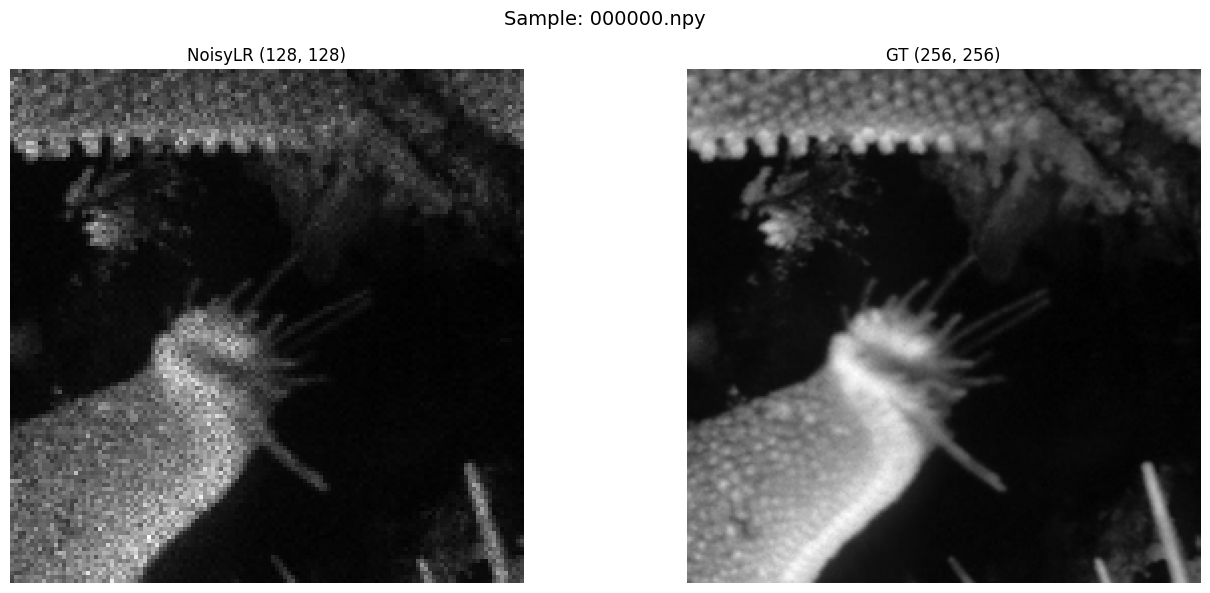

In [5]:
import numpy as np
import matplotlib.pyplot as plt

gt_files = sorted([f for f in os.listdir(TRAIN_GT_DIR) if not f.startswith('.')])
lr_files = sorted([f for f in os.listdir(TRAIN_LR_DIR) if not f.startswith('.')])

print(f"GT images:     {len(gt_files)}")
print(f"NoisyLR images: {len(lr_files)}")
print(f"Matched pairs: {len(set(gt_files) & set(lr_files))}")

# Load first sample
def load_img(path):
    if path.endswith('.npy'):
        return np.load(path).astype(np.float32)
    else:
        import cv2
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        return img.astype(np.float32) if img is not None else None

gt_sample = load_img(os.path.join(TRAIN_GT_DIR, gt_files[0]))
lr_sample = load_img(os.path.join(TRAIN_LR_DIR, lr_files[0]))

print(f"\nGT shape:  {gt_sample.shape}, dtype: {gt_sample.dtype}, range: [{gt_sample.min():.1f}, {gt_sample.max():.1f}]")
print(f"LR shape:  {lr_sample.shape}, dtype: {lr_sample.dtype}, range: [{lr_sample.min():.1f}, {lr_sample.max():.1f}]")

scale = 1
if gt_sample.ndim >= 2 and lr_sample.ndim >= 2:
    scale = gt_sample.shape[0] // lr_sample.shape[0]
print(f"Scale factor: {scale}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(lr_sample, cmap='gray'); axes[0].set_title(f'NoisyLR {lr_sample.shape}'); axes[0].axis('off')
axes[1].imshow(gt_sample, cmap='gray'); axes[1].set_title(f'GT {gt_sample.shape}'); axes[1].axis('off')
plt.suptitle(f'Sample: {lr_files[0]}', fontsize=14)
plt.tight_layout(); plt.show()


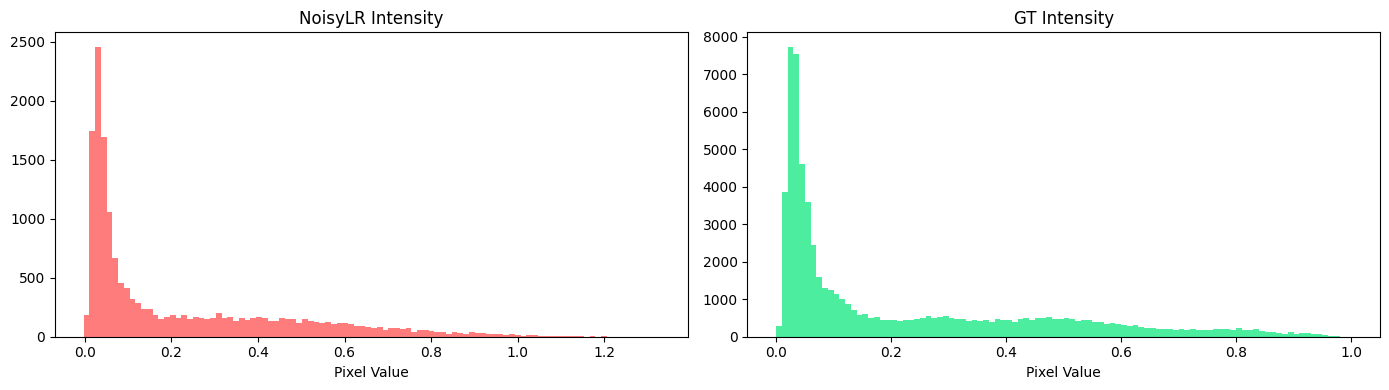

NoisyLR - Mean: 0.22, Std: 0.24
GT      - Mean: 0.22, Std: 0.24


In [6]:
# Intensity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lr_sample.ravel(), bins=100, color='#ff4545', alpha=0.7)
axes[0].set_title('NoisyLR Intensity'); axes[0].set_xlabel('Pixel Value')
axes[1].hist(gt_sample.ravel(), bins=100, color='#00e676', alpha=0.7)
axes[1].set_title('GT Intensity'); axes[1].set_xlabel('Pixel Value')
plt.tight_layout(); plt.show()
print(f"NoisyLR - Mean: {lr_sample.mean():.2f}, Std: {lr_sample.std():.2f}")
print(f"GT      - Mean: {gt_sample.mean():.2f}, Std: {gt_sample.std():.2f}")


## 5. Update Config for Your Data


In [7]:
import yaml

with open(CONFIG) as f:
    config = yaml.safe_load(f)

# Update paths to match your folder structure
config['data']['train_gt'] = os.path.relpath(TRAIN_GT_DIR, DATA_DIR)
config['data']['train_degraded'] = os.path.relpath(TRAIN_LR_DIR, DATA_DIR)

# Auto-detect scale
if scale != config['model'].get('scale', 2):
    print(f"Updating scale: {config['model']['scale']} -> {scale}")
    config['model']['scale'] = scale

# Update patch size if images are small
if lr_sample.shape[0] < 128 or lr_sample.shape[1] < 128:
    new_patch = min(lr_sample.shape[0], lr_sample.shape[1]) // 2
    new_patch = max(32, (new_patch // 8) * 8)  # Round down to multiple of 8
    print(f"Small images detected. Updating lr_patch_size: {config['training']['lr_patch_size']} -> {new_patch}")
    config['training']['lr_patch_size'] = new_patch

with open(CONFIG, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("\nUpdated config:")
print(yaml.dump(config, default_flow_style=False))



Updated config:
data:
  test_gt: test/GT
  test_lr: test/NoisyLR
  train_degraded: train/NoisyLR
  train_gt: train/GT
loss:
  charbonnier_eps: 0.001
  charbonnier_weight: 1.0
  ssim_weight: 0.1
model:
  dec_blk_nums:
  - 1
  - 1
  - 1
  - 1
  enc_blk_nums:
  - 1
  - 1
  - 1
  - 2
  img_channel: 1
  middle_blk_num: 1
  name: nafnet_tiny
  scale: 2
  width: 16
training:
  batch_size: 8
  lr: 0.001
  lr_patch_size: 64
  max_iters: 15000
  num_workers: 2
  save_interval: 1000
  scheduler: cosine
  val_interval: 500
  warmup_iters: 500
  weight_decay: 0.0001



## 6. Train NAFNet-Tiny

This runs ~15,000 iterations (~2.5h on T4 GPU).
Checkpoints saved to Google Drive every 1,000 iters.

**While this runs, work on your slides!**


In [ ]:
!python train.py \
    --config {CONFIG} \
    --data_dir {DATA_DIR} \
    --save_dir {SAVE_DIR} \
    --max_iters 15000


Using device: cuda
Loading data from: /content/drive/MyDrive/Drop/train/NoisyLR -> /content/drive/MyDrive/Drop/train/GT
/content/semicon-restore/train.py:155: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Starting training...
/content/semicon-restore/train.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/content/semicon-restore/train.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
[iter 500/15000] loss=0.0795 | val_psnr=23.36 | val_ssim=0.850 | lr=1.0e-03 | ETA: 1h24m
  -> Saved new best model (PSNR: 23.36)
[iter 1000/15000] loss=0.0924 | val_psnr=23.42 | val_ssim=0.850 | lr=1.0e-03 | ETA: 51m40s
  -> Saved new best model (PSNR: 23.42)
[iter 1500/15000] loss=0.1249 | val_psnr=23.74 

### Resume from Checkpoint (if Colab disconnected)


In [ ]:
#import glob
#ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, 'checkpoint_*.pt')))
#if ckpts:
#     print(f"Resuming from: {ckpts[-1]}")
#     !python train.py --config {CONFIG} --data_dir {DATA_DIR} --save_dir {SAVE_DIR} --resume {ckpts[-1]} --max_iters 15000
#else:
#     print("No checkpoints found.")


No checkpoints found.


## 7. Evaluate


In [11]:
import glob, shutil

# Find best weights
best = os.path.join(SAVE_DIR, 'best_model.pt')
if not os.path.exists(best):
    ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, 'checkpoint_*.pt')))
    best = ckpts[-1] if ckpts else None

if best:
    os.makedirs('weights', exist_ok=True)
    shutil.copy2(best, 'weights/nafnet_tiny.pt')
    print(f"Using: {best} ({os.path.getsize(best)/1e6:.1f} MB)")
else:
    print("No trained weights found! Train first.")


Using: /content/drive/MyDrive/semicon-checkpoints/best_model.pt (5.1 MB)


In [12]:
# Evaluate on test set
if TEST_LR_DIR:
    !python evaluate.py \
        --input_dir {TEST_LR_DIR} \
        --output_dir outputs/test_restored \
        --weights weights/nafnet_tiny.pt \
        --config {CONFIG}
else:
    print("No test directory found. Skipping.")


Evaluating on device: cuda
Loaded weights from weights/nafnet_tiny.pt (scale=2)
Model: NAFNet-Tiny | 1,255,972 params | scale=2x
Found 400 files to process.
[50/400] 000049.npy -> (256, 256) (14.3ms)
[100/400] 000099.npy -> (256, 256) (11.0ms)
[150/400] 000149.npy -> (256, 256) (10.4ms)
[200/400] 000199.npy -> (256, 256) (12.1ms)
[250/400] 000249.npy -> (256, 256) (11.6ms)
[300/400] 000299.npy -> (256, 256) (11.2ms)
[350/400] 000349.npy -> (256, 256) (13.1ms)
[400/400] 000399.npy -> (256, 256) (11.1ms)

Processed 400 images
Avg inference: 14.32 ms | 70 FPS
Output dir: outputs/test_restored


In [13]:
# Evaluate on validation split (with PSNR/SSIM metrics)
import tempfile, shutil

n_val = max(1, len(gt_files) // 10)
val_dir = tempfile.mkdtemp()
val_lr = os.path.join(val_dir, 'lr'); os.makedirs(val_lr)
val_gt = os.path.join(val_dir, 'gt'); os.makedirs(val_gt)
val_out = os.path.join(val_dir, 'out'); os.makedirs(val_out)

for f in lr_files[-n_val:]:
    shutil.copy2(os.path.join(TRAIN_LR_DIR, f), val_lr)
for f in gt_files[-n_val:]:
    shutil.copy2(os.path.join(TRAIN_GT_DIR, f), val_gt)

print(f"Validation: {n_val} images")
!python evaluate.py --input_dir {val_lr} --output_dir {val_out} --weights weights/nafnet_tiny.pt --config {CONFIG} --gt_dir {val_gt}

shutil.rmtree(val_dir)


Validation: 320 images
Evaluating on device: cuda
Loaded weights from weights/nafnet_tiny.pt (scale=2)
Model: NAFNet-Tiny | 1,255,972 params | scale=2x
Found 320 files to process.
[50/320] 002929.npy -> (256, 256) (13.5ms)
[100/320] 002979.npy -> (256, 256) (13.2ms)
[150/320] 003029.npy -> (256, 256) (16.1ms)
[200/320] 003079.npy -> (256, 256) (9.5ms)
[250/320] 003129.npy -> (256, 256) (10.2ms)
[300/320] 003179.npy -> (256, 256) (9.5ms)
[320/320] 003199.npy -> (256, 256) (9.9ms)

Processed 320 images
Avg inference: 14.35 ms | 70 FPS
Output dir: /tmp/tmptq14tk6n/out

--- Metrics (vs Ground Truth) ---
Average PSNR: 23.66 dB
Average SSIM: 0.6916


## 8. Visualize Results


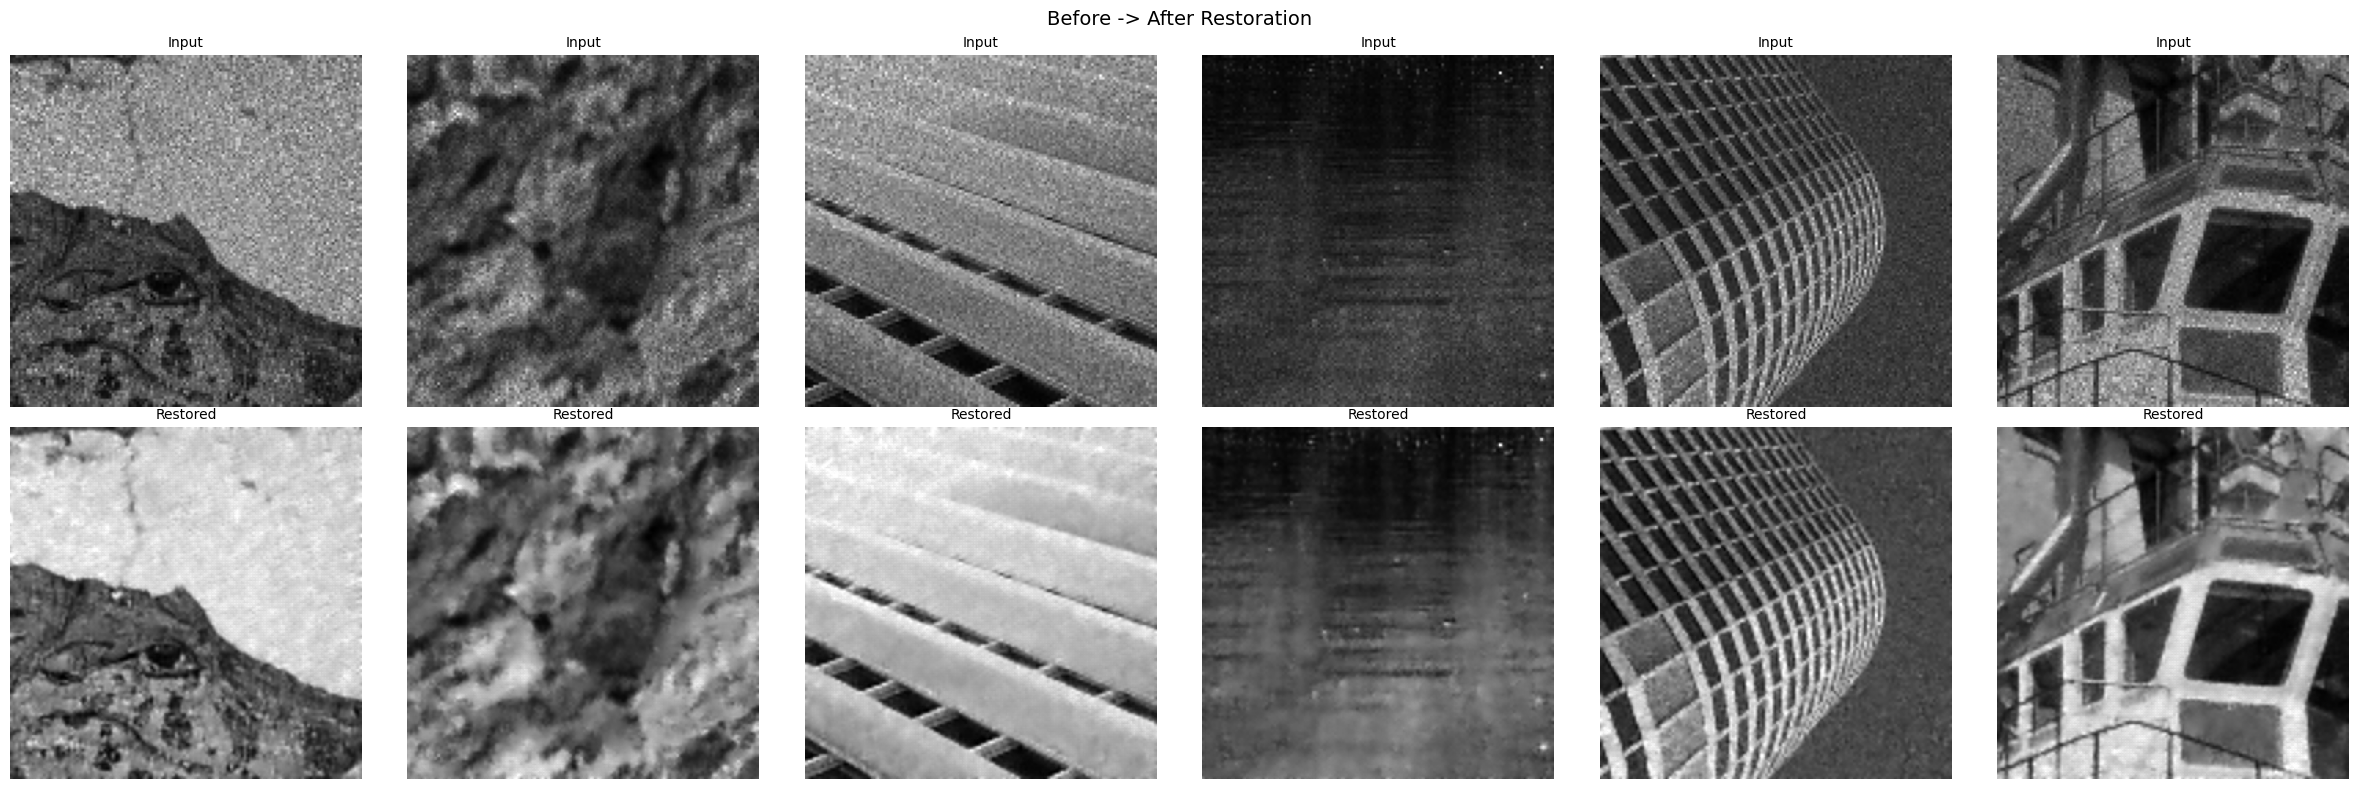

Saved to results_comparison.png


In [14]:
import numpy as np, matplotlib.pyplot as plt, os, cv2

out_dir = 'outputs/test_restored'
if not os.path.exists(out_dir) or not os.listdir(out_dir):
    # Fallback to validation visualization
    print("No test outputs yet. Showing a quick validation sample instead.")
    from models.nafnet_sr import build_model
    import yaml, torch

    with open(CONFIG) as f:
        cfg = yaml.safe_load(f)
    model = build_model(cfg)
    wt = 'weights/nafnet_tiny.pt'
    if os.path.exists(wt):
        model.load_state_dict(torch.load(wt, map_location='cpu')['model_state_dict'] if 'model_state_dict' in torch.load(wt, map_location='cpu') else torch.load(wt, map_location='cpu'))
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    n_show = min(4, len(lr_files))
    fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 12))
    if n_show == 1: axes = axes.reshape(3, 1)

    for i in range(n_show):
        lr = load_img(os.path.join(TRAIN_LR_DIR, lr_files[i]))
        gt = load_img(os.path.join(TRAIN_GT_DIR, gt_files[i]))

        # Normalize and run model
        lr_t = torch.from_numpy(lr / max(lr.max(), 1)).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            out = model(lr_t).squeeze().cpu().numpy()
        out = np.clip(out, 0, 1)

        axes[0, i].imshow(lr, cmap='gray'); axes[0, i].set_title('NoisyLR', fontsize=10); axes[0, i].axis('off')
        axes[1, i].imshow(out, cmap='gray'); axes[1, i].set_title('Restored', fontsize=10); axes[1, i].axis('off')
        axes[2, i].imshow(gt, cmap='gray'); axes[2, i].set_title('Ground Truth', fontsize=10); axes[2, i].axis('off')

    plt.suptitle('NoisyLR -> NAFNet Restored -> GT', fontsize=14)
    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    restored_files = sorted(os.listdir(out_dir))[:6]
    test_input_files = sorted(os.listdir(TEST_LR_DIR))[:6] if TEST_LR_DIR else []
    n = min(len(restored_files), len(test_input_files), 6)

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for i in range(n):
        inp = load_img(os.path.join(TEST_LR_DIR, test_input_files[i]))
        res = load_img(os.path.join(out_dir, restored_files[i]))

        axes[0, i].imshow(inp, cmap='gray'); axes[0, i].set_title('Input', fontsize=10); axes[0, i].axis('off')
        axes[1, i].imshow(res, cmap='gray'); axes[1, i].set_title('Restored', fontsize=10); axes[1, i].axis('off')

    plt.suptitle('Before -> After Restoration', fontsize=14)
    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
print("Saved to results_comparison.png")


## 9. Model Info & Speed Benchmark


In [15]:
import torch, time, yaml, numpy as np
from models.nafnet_sr import build_model

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)
model = build_model(cfg).eval()

n_params = sum(p.numel() for p in model.parameters())
size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
print(f"Model:      NAFNet-Tiny")
print(f"Parameters: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"Size:       {size_mb:.1f} MB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
dummy = torch.randn(1, 1, 128, 128).to(device)

# Warmup
for _ in range(20):
    with torch.no_grad(): _ = model(dummy)
if torch.cuda.is_available(): torch.cuda.synchronize()

# Benchmark
times = []
for _ in range(100):
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad(): _ = model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    times.append((time.perf_counter() - t0) * 1000)

print(f"\n128x128 -> 256x256:")
print(f"  {np.mean(times):.2f} ms avg | {1000/np.mean(times):.0f} FPS")


Model:      NAFNet-Tiny
Parameters: 1,255,972 (1.26M)
Size:       5.0 MB

128x128 -> 256x256:
  10.23 ms avg | 98 FPS


## 🔬 Interactive Demo — Upload & Restore

Upload a `.npy` semiconductor image and see the NAFNet restoration in real-time.
- **Accepted**: `.npy` files, grayscale, dimensions 128×128 or 256×256
- **Output**: 2× super-resolved + denoised image

In [17]:
# ═══════════════════════════════════════════════════════════
# Interactive Demo: Upload .npy → Restore with NAFNet
# ═══════════════════════════════════════════════════════════
import numpy as np
import torch
import yaml
import io
import os
import base64
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from models.nafnet_sr import build_model
from google.colab import output
from IPython.display import display, HTML, JSON

# ---- Load model once ----
_demo_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with open(CONFIG) as f:
    _demo_cfg = yaml.safe_load(f)
_demo_model = build_model(_demo_cfg).to(_demo_device).eval()

_wt_path = 'weights/nafnet_tiny.pt'
if os.path.exists(_wt_path):
    _ckpt = torch.load(_wt_path, map_location=_demo_device, weights_only=False)
    if isinstance(_ckpt, dict) and 'model_state' in _ckpt:
        _demo_model.load_state_dict(_ckpt['model_state'])
    elif isinstance(_ckpt, dict) and 'model_state_dict' in _ckpt:
        _demo_model.load_state_dict(_ckpt['model_state_dict'])
    else:
        _demo_model.load_state_dict(_ckpt)
    print(f'Model loaded from {_wt_path} on {_demo_device}')
else:
    print(f'WARNING: {_wt_path} not found — running with untrained weights')

_demo_scale = _demo_cfg.get('model', {}).get('scale', 2)
VALID_DIMS = [(128, 128), (256, 256)]

# ---- Processing function called from JS ----
def process_uploaded_npy(data_b64, filename):
    """Receives base64-encoded .npy data from JS, validates, restores, returns JSON result."""
    try:
        raw = base64.b64decode(data_b64)
        arr = np.load(io.BytesIO(raw))
    except Exception as e:
        return JSON({'error': f'Failed to parse .npy file: {str(e)}'})

    # ---- Validate Dimensions & Types ----
    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[2] == 1:
            arr = arr[:, :, 0]

    if arr.ndim != 2:
        return JSON({'error': f'Expected 2D grayscale image array, but got shape {arr.shape}.'})

    h, w = arr.shape
    if (h, w) not in VALID_DIMS:
        return JSON({'error': f'Invalid dimension {h}×{w}. Model expects degraded test images at 128×128 or 256×256.'})

    if not np.issubdtype(arr.dtype, np.floating) and not np.issubdtype(arr.dtype, np.integer):
        return JSON({'error': f'Unsupported dtype: {arr.dtype}. Expected float32/float64 or integer array.'})

    # ---- Normalize ----
    img = arr.astype(np.float32)
    if img.max() > 1.0:
        img = img / img.max()

    # ---- Inference ----
    try:
        inp_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(_demo_device)
        with torch.no_grad():
            out_t = _demo_model(inp_t)
        out_np = np.clip(out_t.squeeze().cpu().numpy(), 0.0, 1.0)
    except Exception as e:
        return JSON({'error': f'Model inference error: {str(e)}'})

    out_h, out_w = out_np.shape

    # ---- Create comparison figure ----
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Input ({h}×{w})', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(out_np, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'Restored ({out_h}×{out_w})', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.suptitle(f'{filename} — NAFNet-Tiny {_demo_scale}× SR + Denoise',
                 fontsize=13, fontweight='bold', color='#222')
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')

    return JSON({
        'image': img_b64,
        'input_shape': f'{h}×{w}',
        'output_shape': f'{out_h}×{out_w}',
        'input_range': f'[{arr.min():.3f}, {arr.max():.3f}]',
        'output_range': f'[{out_np.min():.3f}, {out_np.max():.3f}]',
    })

output.register_callback('notebook.process_npy', process_uploaded_npy)

# ---- HTML/JS Upload Widget ----
display(HTML("""
<style>
  .demo-container {
    font-family: 'Segoe UI', Roboto, sans-serif;
    max-width: 720px;
    margin: 12px auto;
    padding: 20px;
    border: 2px solid #2e7d32;
    border-radius: 12px;
    background: #fafafa;
  }
  .demo-container h3 {
    margin: 0 0 6px 0;
    color: #1b5e20;
  }
  .demo-container .subtitle {
    color: #666; font-size: 13px; margin-bottom: 16px;
  }
  .drop-zone {
    border: 2px dashed #4caf50;
    border-radius: 10px;
    padding: 32px 20px;
    text-align: center;
    cursor: pointer;
    background: #fff;
    transition: all 0.2s;
    color: #444;
    font-size: 14px;
  }
  .drop-zone:hover, .drop-zone.dragover {
    border-color: #2e7d32;
    background: #e8f5e9;
    color: #1b5e20;
  }
  .drop-zone input[type=file] { display: none; }
  .error-box {
    background: #ffebee; color: #c62828; border: 1px solid #ef9a9a;
    padding: 10px 14px; border-radius: 8px; margin-top: 12px;
    font-size: 13px; display: none;
  }
  .status-box {
    padding: 10px 14px; border-radius: 8px; margin-top: 12px;
    font-size: 13px; display: none; text-align: center;
    background: #e3f2fd; color: #1565c0; border: 1px solid #90caf9;
  }
  .result-box {
    margin-top: 16px; display: none;
  }
  .result-box img {
    max-width: 100%; border-radius: 8px;
    border: 1px solid #ddd;
  }
  .meta-grid {
    display: grid; grid-template-columns: 1fr 1fr;
    gap: 6px; margin-top: 10px; font-size: 12px; color: #555;
  }
  .meta-grid span { background: #f0f0f0; padding: 4px 8px; border-radius: 4px; }
</style>

<div class="demo-container">
  <h3>🔬 Upload &amp; Restore (.npy)</h3>
  <p class="subtitle">Drop or select a degraded <code>.npy</code> image (128×128 or 256×256) to restore</p>

  <div class="drop-zone" id="dropZone" onclick="document.getElementById('fileInput').click()">
    📂 Click or drag &amp; drop a <b>.npy</b> file here
    <input type="file" id="fileInput" accept=".npy">
  </div>

  <div class="error-box" id="errorBox"></div>
  <div class="status-box" id="statusBox">⏳ Processing...</div>

  <div class="result-box" id="resultBox">
    <img id="resultImg" />
    <div class="meta-grid" id="metaGrid"></div>
  </div>
</div>

<script>
  const dropZone = document.getElementById('dropZone');
  const fileInput = document.getElementById('fileInput');
  const errorBox = document.getElementById('errorBox');
  const statusBox = document.getElementById('statusBox');
  const resultBox = document.getElementById('resultBox');
  const resultImg = document.getElementById('resultImg');
  const metaGrid = document.getElementById('metaGrid');

  function showError(msg) {
    errorBox.innerHTML = '<strong>✕ Error:</strong> ' + msg;
    errorBox.style.display = 'block';
    statusBox.style.display = 'none';
    resultBox.style.display = 'none';
  }

  function clearState() {
    errorBox.style.display = 'none';
    statusBox.style.display = 'none';
    resultBox.style.display = 'none';
  }

  async function handleFile(file) {
    clearState();

    if (!file.name.toLowerCase().endsWith('.npy')) {
      showError('Only <code>.npy</code> files are accepted. Got: <code>' + file.name + '</code>');
      return;
    }

    statusBox.innerHTML = '⏳ Processing <b>' + file.name + '</b> with NAFNet...';
    statusBox.style.display = 'block';

    const reader = new FileReader();
    reader.onload = async function(e) {
      try {
        const dataUrl = e.target.result;
        const b64 = dataUrl.split(',')[1];

        const result = await google.colab.kernel.invokeFunction('notebook.process_npy', [b64, file.name], {});

        let data = null;
        if (result && result.data) {
          if (result.data['application/json']) {
            data = result.data['application/json'];
          } else if (result.data['text/plain']) {
            try {
              data = JSON.parse(result.data['text/plain']);
            } catch(pe) {
              data = { error: result.data['text/plain'] };
            }
          }
        } else if (result && typeof result === 'object') {
          data = result;
        }

        if (!data) {
          showError('No valid response received from kernel.');
          return;
        }

        if (data.error) {
          showError(data.error);
          return;
        }

        resultImg.src = 'data:image/png;base64,' + data.image;
        metaGrid.innerHTML =
          '<span>📥 Input: ' + data.input_shape + '</span>' +
          '<span>📤 Output: ' + data.output_shape + '</span>' +
          '<span>Range in: ' + data.input_range + '</span>' +
          '<span>Range out: ' + data.output_range + '</span>';

        statusBox.style.display = 'none';
        resultBox.style.display = 'block';
      } catch(err) {
        showError('Model processing failed: ' + err.message);
      }
    };
    reader.readAsDataURL(file);
  }

  fileInput.addEventListener('change', (e) => { if (e.target.files[0]) handleFile(e.target.files[0]); });
  dropZone.addEventListener('dragover', (e) => { e.preventDefault(); dropZone.classList.add('dragover'); });
  dropZone.addEventListener('dragleave', () => { dropZone.classList.remove('dragover'); });
  dropZone.addEventListener('drop', (e) => {
    e.preventDefault();
    dropZone.classList.remove('dragover');
    if (e.dataTransfer.files[0]) handleFile(e.dataTransfer.files[0]);
  });
</script>
"""))
print('Demo widget ready. Upload a .npy file above.')


Model loaded from weights/nafnet_tiny.pt on cuda


Demo widget ready. Upload a .npy file above.


## 10. Push Results to GitHub


In [21]:
from google.colab import files

# Download the model weights and results image
files.download('weights/nafnet_tiny.pt')
files.download('results_comparison.png')
files.download('best')

FileNotFoundError: Cannot find file: .gitkeep

---
## Checklist

- [ ] GPU = T4, CUDA working
- [ ] Data loaded correctly (GT + NoisyLR found)
- [ ] Training completed (15k iters, PSNR >= 28 dB)
- [ ] evaluate.py runs with --weights weights/nafnet_tiny.pt
- [ ] Test outputs saved in outputs/
- [ ] Results look visually correct
- [ ] Fresh clone test passes

